# Some visualizations with quality scores (DCLM, FineWebEdu, and 4 perplexity correlations filters)

We have 6 scores: `dclm_score`, `fwedu_score` (0-5 discretized), and 4 perplexity-correlations fastText filters (`arc_easy`, `piqa`, `sciq`, `lambada`, each a probability of `__label__include`).

We want to decide which filters are worth keeping in the hierarchical Bayesian model, and what likelihood/transformation each needs.

**Questions to consider**
- Likelihood choice: approx Gaussian? heavy-tailed? bounded [0,1]? bimodal?
- Redundancy: which pairs correlate > 0.9 (candidates to drop)?
- Topic/format resolution: how much does raw score depend on topic? (motivates within-topic percentile)
- Length artifact: does a filter effectively reward length?

In [4]:
import json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
sys.path.insert(0, "/juice5b/scr5b/kaitwang/stats305c/WebOrganizer/milestone2")

from config import DATA_ROOT, ANNOTATIONS_PARQUET, shard_stem

sns.set_context('notebook')
plt.rcParams['figure.dpi'] = 100

PC_MODELS = ['arc_easy', 'piqa', 'sciq', 'lambada']
SCORE_COLS = ['dclm_score', 'fwedu_score'] + PC_MODELS

In [ ]:
# load annotations (all 100 shards) and merge perplexity correlations scores into big pd table
annot = pd.read_parquet(ANNOTATIONS_PARQUET)
print(f'{len(annot):,} docs, {annot.shard_idx.nunique()} shards')

shards = sorted(annot.shard_idx.unique())
for m in PC_MODELS:
    chunks = []
    for s in shards:
        p = DATA_ROOT / 'scores_pc' / m / f'{shard_stem(s)}.npy'
        arr = np.load(p) if p.exists() else np.full(int((annot.shard_idx == s).sum()), np.nan, np.float32)
        chunks.append(arr)
    annot[m] = np.concatenate(chunks)
print(annot[SCORE_COLS].describe())

2,263,456 docs, 100 shards
         dclm_score    fwedu_score      arc_easy          piqa          sciq  \
count  2.263456e+06  292846.000000  2.263456e+06  2.263456e+06  2.263456e+06   
mean   1.624947e-02       1.122190  7.647538e-01  8.076773e-01  8.243372e-01   
std    7.949493e-02       0.652324  1.383018e-01  1.232385e-01  1.210008e-01   
min   -1.001358e-05      -0.800781 -9.655952e-06 -9.417534e-06  7.987022e-06   
25%   -3.099442e-06       0.710938  7.022289e-01  7.558747e-01  7.694155e-01   
50%    2.062917e-04       1.000000  7.928084e-01  8.344028e-01  8.529344e-01   
75%    2.861947e-03       1.414062  8.609919e-01  8.917749e-01  9.104595e-01   
max    1.000010e+00       4.750000  9.999996e-01  1.000007e+00  9.999925e-01   

            lambada  
count  2.263456e+06  
mean   1.161643e-01  
std    7.881415e-02  
min   -1.001358e-05  
25%    5.948156e-02  
50%    9.591818e-02  
75%    1.526413e-01  
max    9.535339e-01  


## 1. Marginal distributions  

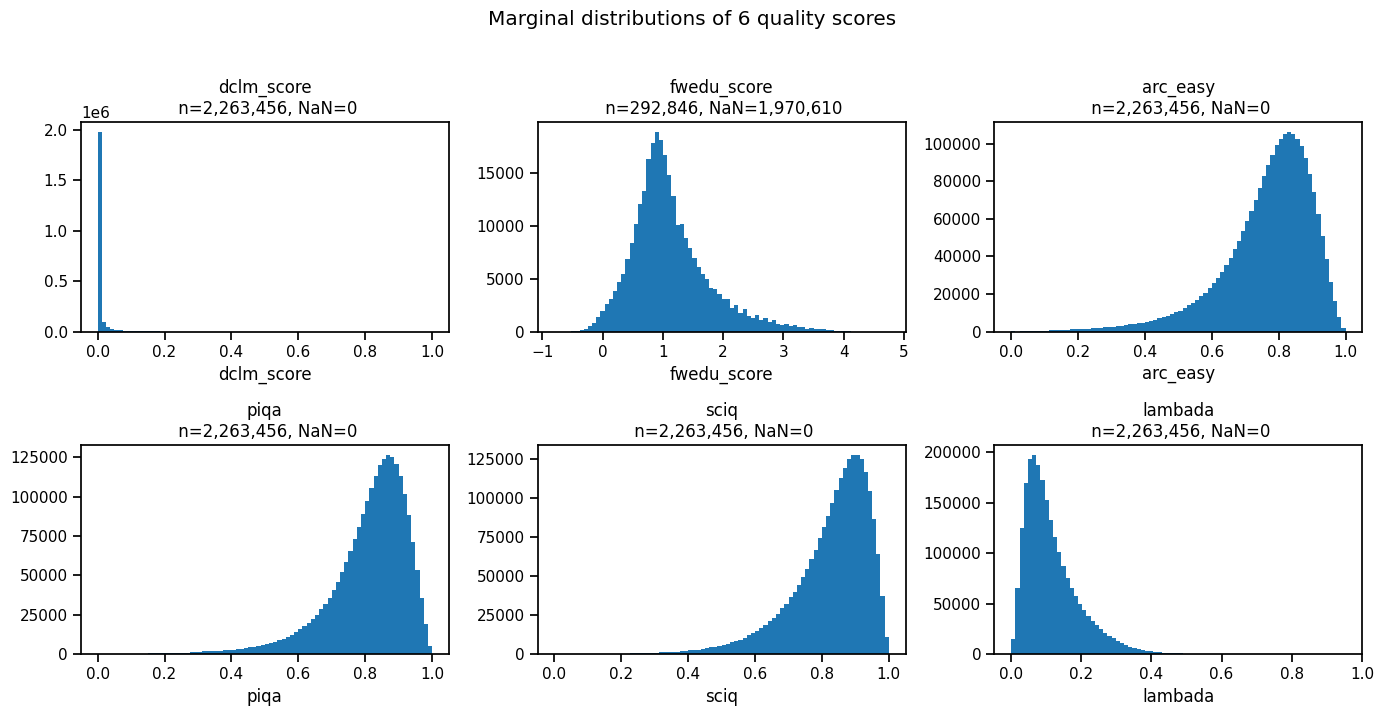

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flat, SCORE_COLS):
    x = annot[c].dropna()
    ax.hist(x, bins=80)
    ax.set_title(f'{c}\n n={len(x):,}, NaN={annot[c].isna().sum():,}')
    ax.set_xlabel(c)
fig.suptitle('Marginal distributions of 6 quality scores', y=1.02)
fig.tight_layout(); plt.show()

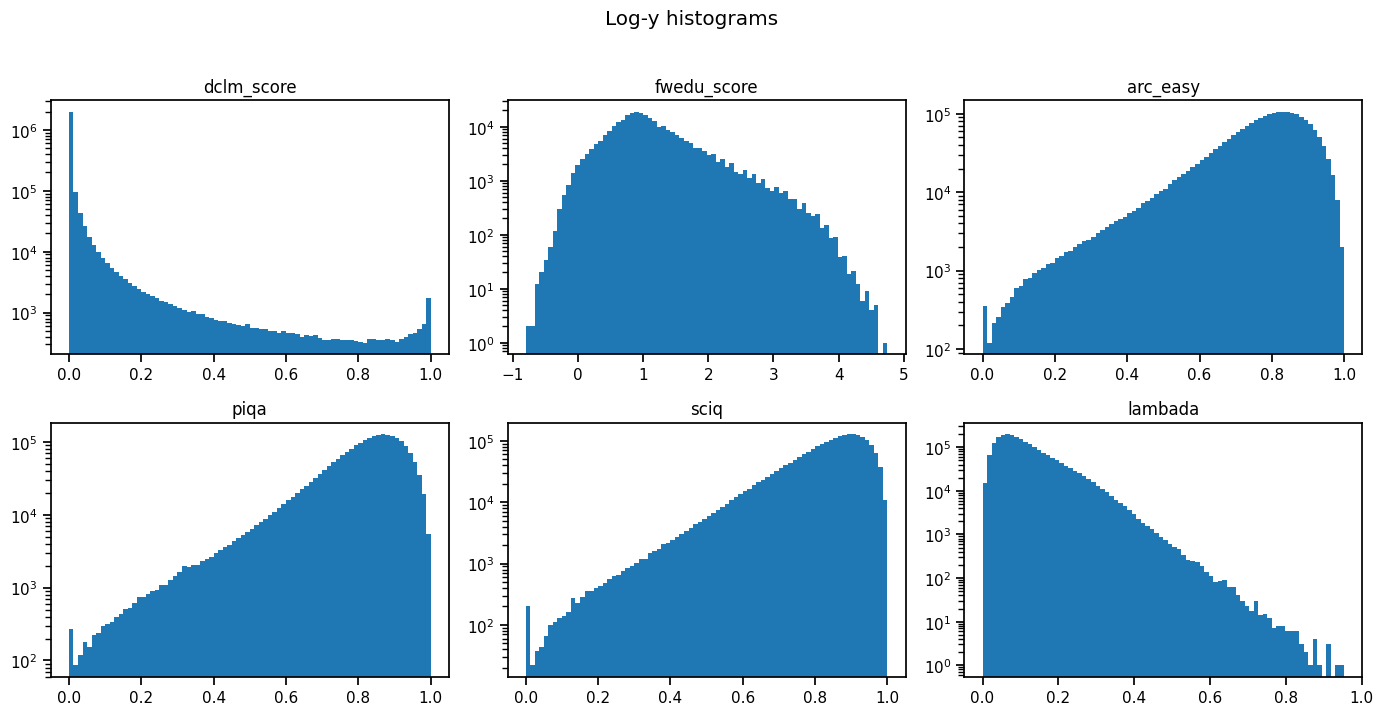

In [18]:
# Same but log y-axis: exposes heavy tails and rare extreme values.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flat, SCORE_COLS):
    x = annot[c].dropna()
    ax.hist(x, bins=80)
    ax.set_yscale('log')
    ax.set_title(c)
fig.suptitle('Log-y histograms', y=1.02)
fig.tight_layout(); plt.show()

In [8]:
# Summary table: mean/std, skew, kurtosis, % at boundary. Guides likelihood choice.
def summarize(x, name):
    x = x.dropna().values
    return {'score': name, 'n': len(x),
            'mean': x.mean(), 'std': x.std(),
            'min': x.min(), 'max': x.max(),
            'skew': stats.skew(x), 'kurt': stats.kurtosis(x),
            'frac<=0.01': np.mean(x <= 0.01) if x.max() <= 1.5 else np.nan,
            'frac>=0.99': np.mean(x >= 0.99) if x.max() <= 1.5 else np.nan}
pd.DataFrame([summarize(annot[c], c) for c in SCORE_COLS]).round(3)

,score,n,mean,std,min,max,skew,kurt,frac<=0.01,frac>=0.99
0,dclm_score,2263456,0.016,0.079,-0.000,1.000,8.361,79.863998,0.856,0.001
1,fwedu_score,292846,1.122,0.652,-0.801,4.750,1.079,1.796000,NaN,NaN
2,arc_easy,2263456,0.765,0.138,-0.000,1.000,-1.421,2.917000,0.000,0.001
3,piqa,2263456,0.808,0.123,-0.000,1.000,-1.686,4.422000,0.000,0.002
4,sciq,2263456,0.824,0.121,0.000,1.000,-1.544,3.508000,0.000,0.003
5,lambada,2263456,0.116,0.079,-0.000,0.954,1.482,3.147000,0.004,0.000


## 2. Pairwise structure

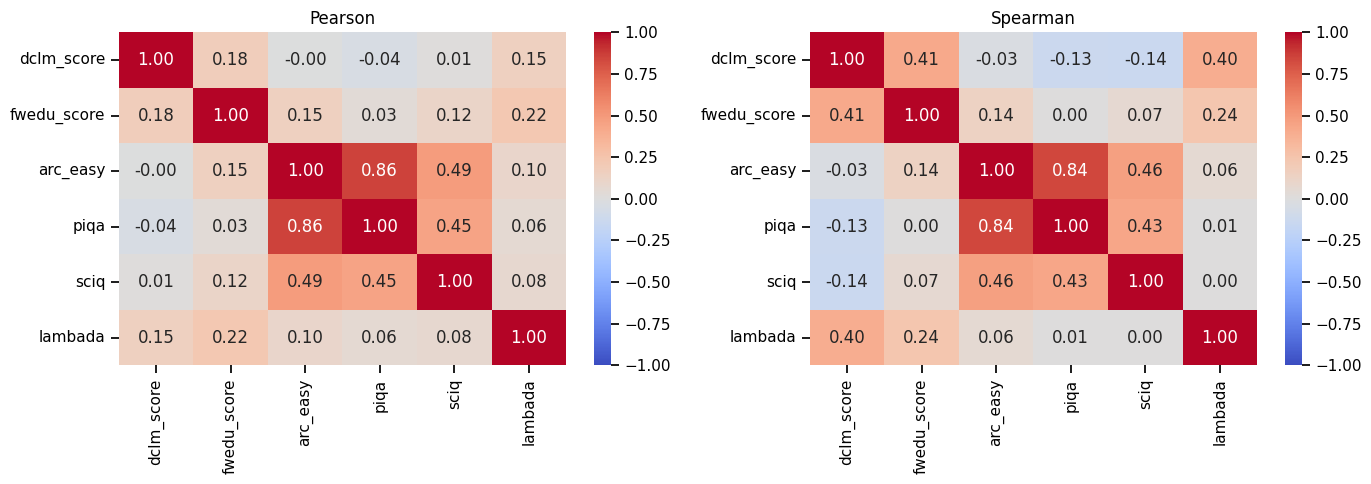

In [19]:
X = annot[SCORE_COLS].dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(X.corr('pearson'),  annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[0])
sns.heatmap(X.corr('spearman'), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[0].set_title('Pearson'); axes[1].set_title('Spearman')
fig.tight_layout(); plt.show()

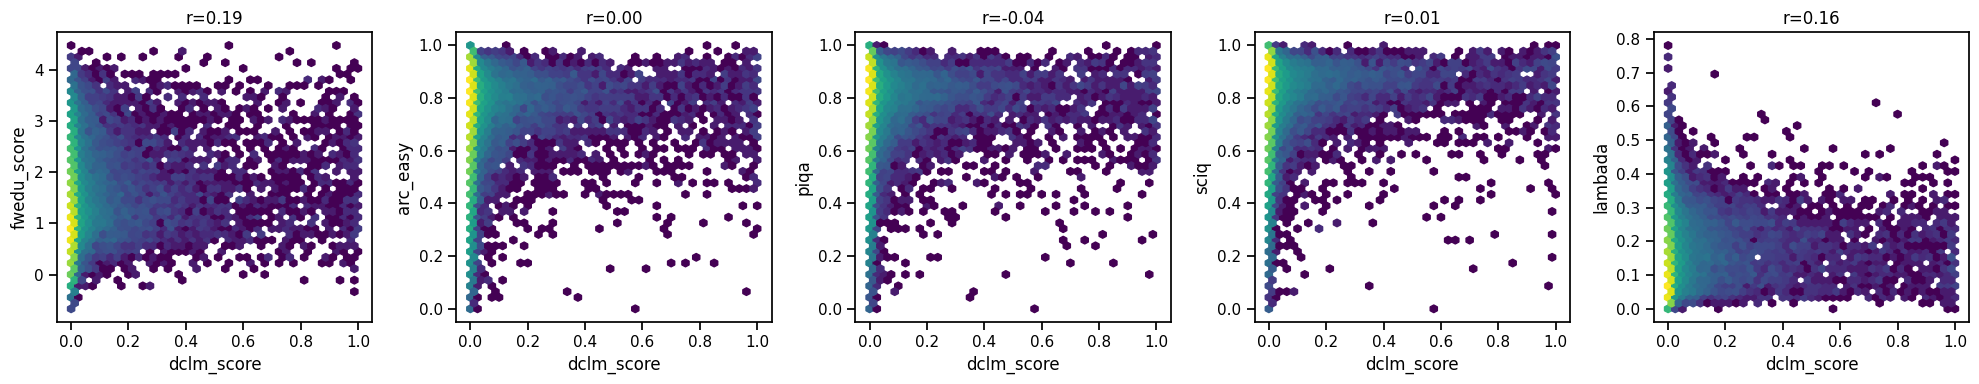

In [20]:
# checking for redundancy with DCLM
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, c in zip(axes, [col for col in SCORE_COLS if col != 'dclm_score']):
    sub = X.sample(min(100_000, len(X)), random_state=0)
    ax.hexbin(sub['dclm_score'], sub[c], gridsize=40, bins='log', cmap='viridis')
    r = sub[['dclm_score', c]].corr().iloc[0,1]
    ax.set_xlabel('dclm_score'); ax.set_ylabel(c); ax.set_title(f'r={r:.2f}')
fig.tight_layout(); plt.show()

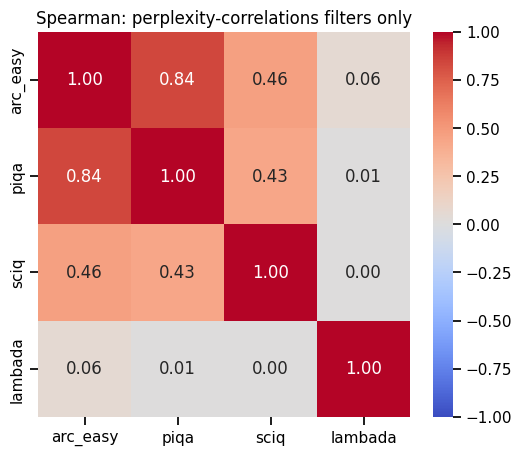

In [21]:
# do the 4 perplexity-correlations filters cluster together? (they should since they're constructed similarly)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(X[PC_MODELS].corr('spearman'), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Spearman: perplexity-correlations filters only')
plt.show()

## 3. Scores by topic and format

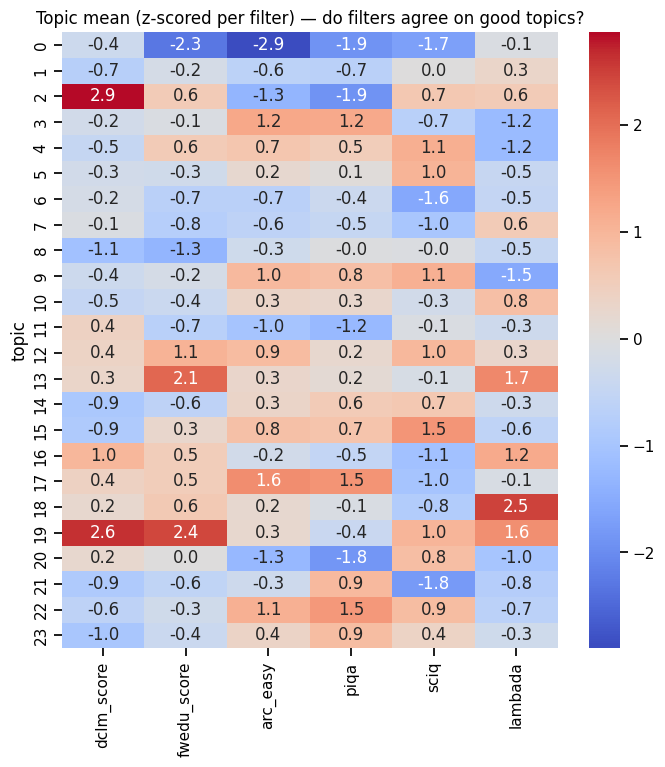

In [22]:
# topic mean heatmap (topics × filters), z-scored per filter so topics are comparable across filters
topic_means = annot.groupby('topic')[SCORE_COLS].mean()
topic_means_z = (topic_means - topic_means.mean()) / topic_means.std()
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(topic_means_z, annot=True, fmt='.1f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Topic mean (z-scored per filter) — do filters agree on good topics?')
plt.show()

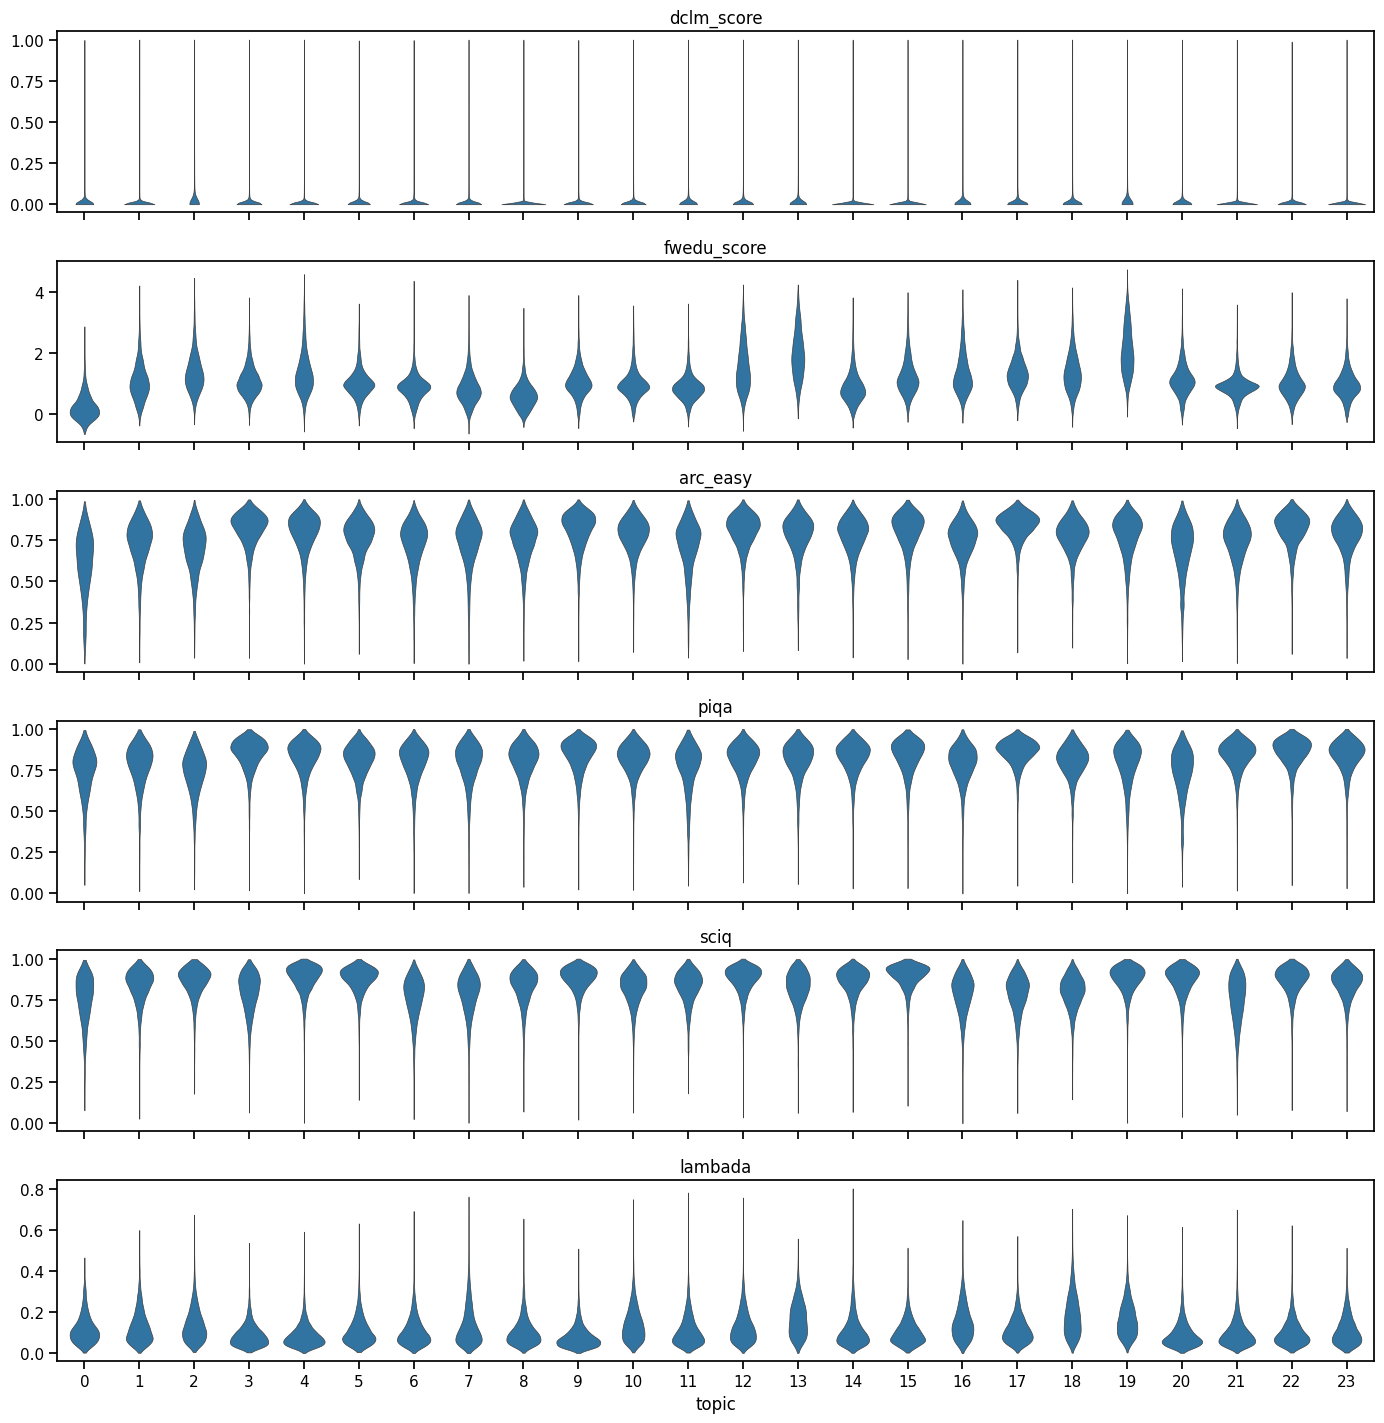

In [13]:
# Violin of each score across 24 topics (sampled to keep render fast).
sub = annot.dropna(subset=SCORE_COLS).sample(min(200_000, len(annot)), random_state=0)
fig, axes = plt.subplots(len(SCORE_COLS), 1, figsize=(14, 2.4*len(SCORE_COLS)), sharex=True)
for ax, c in zip(axes, SCORE_COLS):
    sns.violinplot(data=sub, x='topic', y=c, inner=None, ax=ax, cut=0, linewidth=0.5)
    ax.set_title(c); ax.set_ylabel('')
fig.tight_layout(); plt.show()

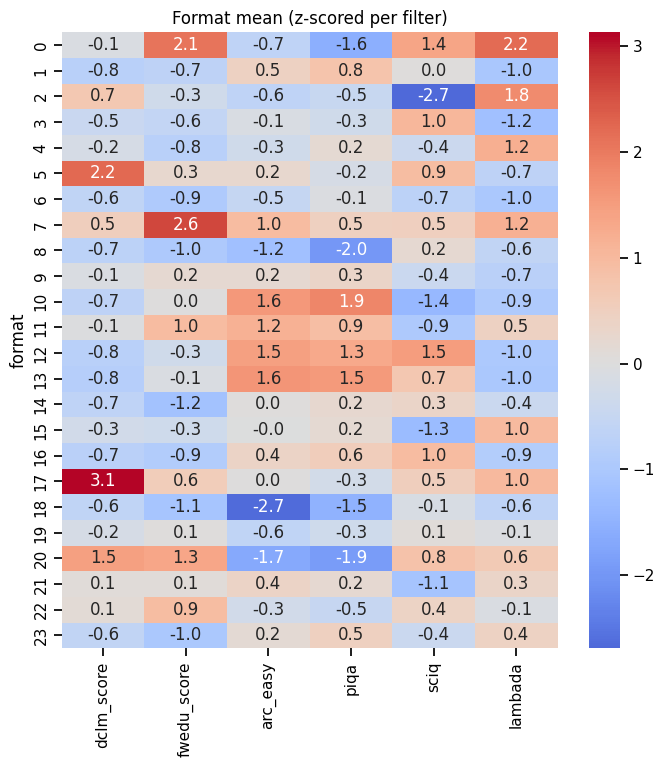

In [ ]:
# format mean heatmap
fmt_means = annot.groupby('format')[SCORE_COLS].mean()
fmt_means_z = (fmt_means - fmt_means.mean()) / fmt_means.std()
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(fmt_means_z, annot=True, fmt='.1f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Format mean (z-scored per filter)')
plt.show()

## 4. Length sensitivity

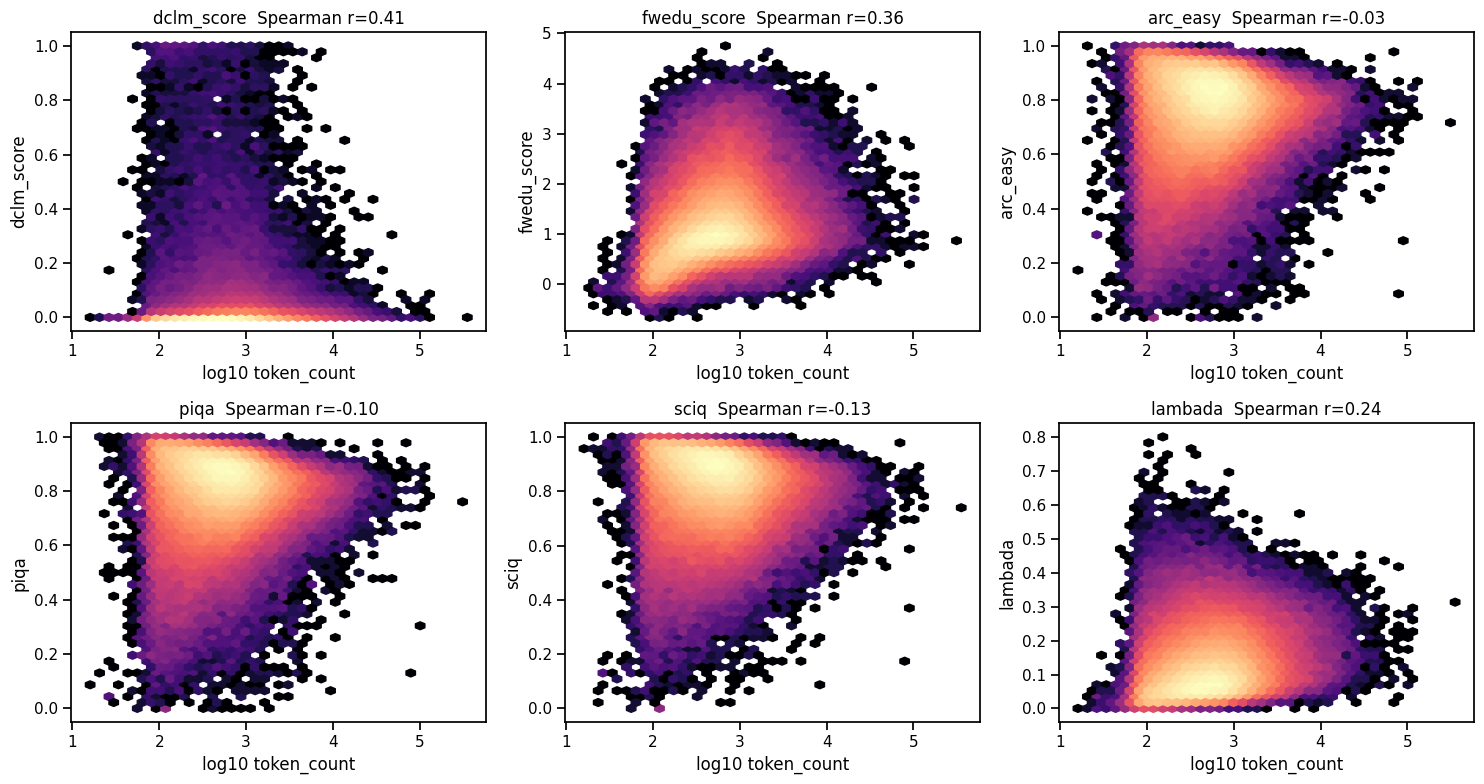

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sub = annot.dropna(subset=SCORE_COLS + ['token_count']).sample(min(200_000, len(annot)), random_state=0)
for ax, c in zip(axes.flat, SCORE_COLS):
    ax.hexbin(np.log10(sub['token_count'].clip(1)), sub[c], gridsize=40, bins='log', cmap='magma')
    r = stats.spearmanr(sub['token_count'], sub[c]).statistic
    ax.set_xlabel('log10 token_count'); ax.set_ylabel(c); ax.set_title(f'{c}  Spearman r={r:.2f}')
fig.tight_layout(); plt.show()

## 5. Global rank agreement

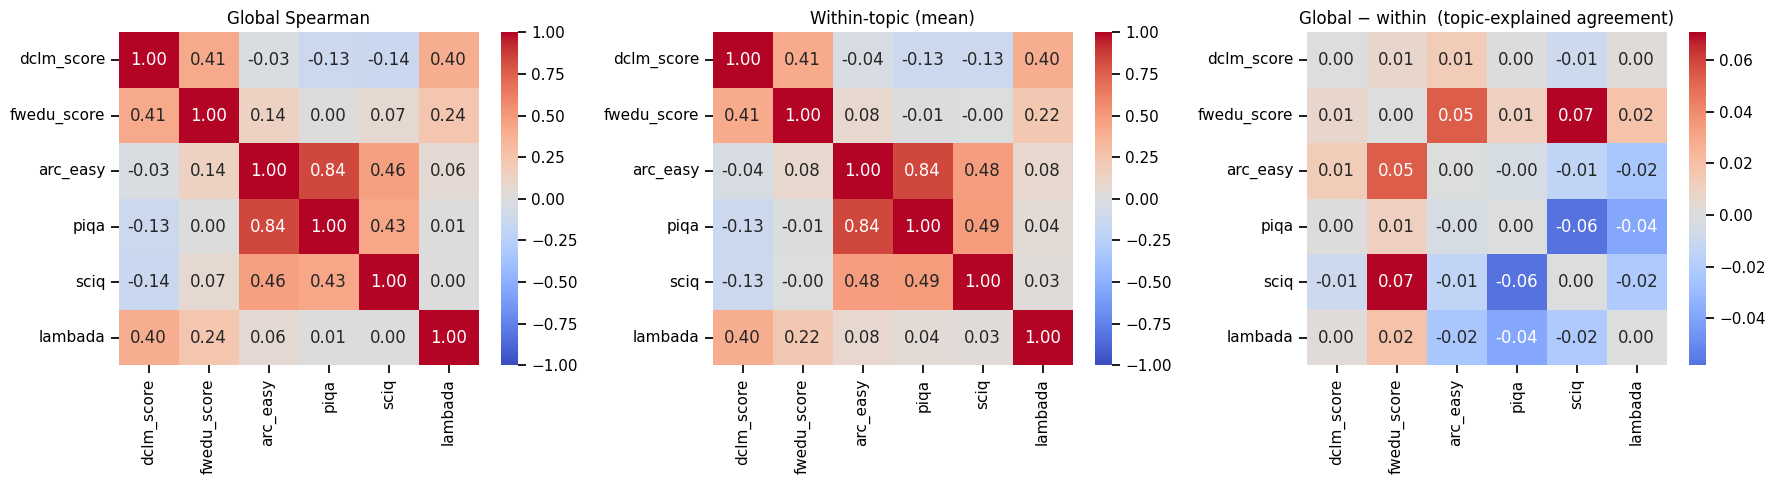

In [ ]:
# within-topic Spearman, averaged across topics
def within_topic_spearman(df, cols):
    out = np.zeros((len(cols), len(cols)))
    for t, g in df.groupby('topic'):
        if len(g) < 100: continue
        out += g[cols].corr('spearman').values
    return out / df['topic'].nunique()
global_s = X.corr('spearman').values
within_s = within_topic_spearman(annot.dropna(subset=SCORE_COLS), SCORE_COLS)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(global_s, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, xticklabels=SCORE_COLS, yticklabels=SCORE_COLS, ax=axes[0])
sns.heatmap(within_s, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, xticklabels=SCORE_COLS, yticklabels=SCORE_COLS, ax=axes[1])
sns.heatmap(global_s - within_s, annot=True, fmt='.2f', cmap='coolwarm', center=0, xticklabels=SCORE_COLS, yticklabels=SCORE_COLS, ax=axes[2])
axes[0].set_title('Global Spearman'); axes[1].set_title('Within-topic (mean)'); axes[2].set_title('Global − within  (topic-explained agreement)')
fig.tight_layout(); plt.show()